In [1]:
import random
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class QNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.hidden = nn.Linear(4, hidden_dim)
        self.output = nn.Linear(hidden_dim, 2)

    def forward(self, s):
        outs = self.hidden(s)
        outs = F.relu(outs)
        outs = self.output(outs)
        return outs

q_model = QNet().to(device)
q_target_model = QNet().to(device)
q_target_model.load_state_dict(q_model.state_dict())
_ = q_target_model.requires_grad_(False)  # target q-network doen't need grad

In [3]:
class replayMemory:
    def __init__(self, buffer_size: int):
        self.buffer_size = buffer_size
        self.buffer = []

    def add(self, item):
        if len(self.buffer) == self.buffer_size:
            self.buffer.pop(0)
        self.buffer.append(item)

    def sample(self, sample_size):
        # sampling
        items = random.sample(self.buffer, sample_size)
        # divide each columns
        states   = [i[0] for i in items]
        actions  = [i[1] for i in items]
        rewards  = [i[2] for i in items]
        n_states = [i[3] for i in items]
        dones    = [i[4] for i in items]
        # convert to tensor
        states = torch.tensor(states, dtype=torch.float).to(device)
        actions = torch.tensor(actions, dtype=torch.int64).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float).to(device)
        n_states = torch.tensor(n_states, dtype=torch.float).to(device)
        dones = torch.tensor(dones, dtype=torch.float).to(device)
        # return result
        return states, actions, rewards, n_states, dones

    def length(self):
        return len(self.buffer)

memory = replayMemory(buffer_size=10000)


In [4]:
gamma = 0.99

opt = torch.optim.Adam(q_model.parameters(), lr=0.0005)

def optimize(states, actions, rewards, next_states, dones):
    #
    # Compute target
    #

    with torch.no_grad():
        # compute Q(s_{t+1})                               : size=[batch_size, 2]
        target_vals_for_all_actions = q_target_model(next_states)
        # compute argmax_a Q(s_{t+1})                      : size=[batch_size]
        target_actions = torch.argmax(target_vals_for_all_actions, 1)
        # compute max Q(s_{t+1})                           : size=[batch_size]
        target_actions_one_hot = F.one_hot(target_actions, env.action_space.n).float()
        target_vals = torch.sum(target_vals_for_all_actions * target_actions_one_hot, 1)
        # compute r_t + gamma * (1 - d_t) * max Q(s_{t+1}) : size=[batch_size]
        target_vals_masked = (1.0 - dones) * target_vals
        q_vals1 = rewards + gamma * target_vals_masked

    opt.zero_grad()

    #
    # Compute q-value
    #
    actions_one_hot = F.one_hot(actions, env.action_space.n).float()
    q_vals2 = torch.sum(q_model(states) * actions_one_hot, 1)

    #
    # Get MSE loss and optimize
    #
    loss = F.mse_loss(
        q_vals1.detach(),
        q_vals2,
        reduction="mean")
    loss.backward()
    opt.step()

In [5]:
sampling_size = 64 * 30
batch_size = 64

epsilon = 1.0
epsilon_decay = epsilon / 3000
epsilon_final = 0.1

env = gym.make("CartPole-v1")

# pick up action from q-network with greedy exploration
def pick_sample(s, epsilon):
    with torch.no_grad():
        # get optimal action,
        # but with greedy exploration (to prevent picking up same values in the first stage)
        if np.random.random() > epsilon:
            s_batch = torch.tensor(s, dtype=torch.float).to(device)
            s_batch = s_batch.unsqueeze(dim=0)  # to make batch with size=1
            q_vals_for_all_actions = q_model(s_batch)
            a = torch.argmax(q_vals_for_all_actions, 1)
            a = a.squeeze(dim=0)
            a = a.tolist()
        else:
            a = np.random.randint(0, env.action_space.n)
        return a

# evaluate current agent with no exploration
def evaluate():
    with torch.no_grad():
        s, _ = env.reset()
        done = False
        total = 0
        while not done:
            a = pick_sample(s, 0.0)
            s_next, r, term, trunc, _ = env.step(a)
            done = term or trunc
            total += r
            s = s_next
        return total

reward_records = []
for _ in range(15000):
    # Run episode till it picks up 500 samples
    # (All samples are stored in reply memory.)
    done = True
    for _ in range(500):
        if done:
            s, _ = env.reset()
            done = False
            cum_reward = 0

        a = pick_sample(s, epsilon)
        s_next, r, term, trunc, _ = env.step(a)
        done = term or trunc
        memory.add([s.tolist(), a, r, s_next.tolist(), float(term)])  # (see above note for truncation)
        cum_reward += r
        s = s_next

    # Init replay memory (without updates) till 2000 samples are filled
    if memory.length() < 2000:
        continue

    # Optimize Q-network with a batch from replay memory
    states, actions, rewards, n_states, dones = memory.sample(sampling_size)
    states = torch.reshape(states, (-1, batch_size, 4))
    actions = torch.reshape(actions, (-1, batch_size))
    rewards = torch.reshape(rewards, (-1, batch_size))
    n_states = torch.reshape(n_states, (-1, batch_size, 4))
    dones = torch.reshape(dones, (-1, batch_size))
    for j in range(actions.size(dim=0)):
        optimize(states[j], actions[j], rewards[j], n_states[j], dones[j])
    total_reward = evaluate()
    reward_records.append(total_reward)
    iteration_num = len(reward_records)
    print("Run iteration {} rewards {:3} epsilon {:1.5f}".format(iteration_num, total_reward, epsilon), end="\r")

    # Clone Q-network to obtain target
    if iteration_num % 50 == 0:
        q_target_model.load_state_dict(q_model.state_dict())

    # Update epsilon
    if epsilon - epsilon_decay >= epsilon_final:
        epsilon -= epsilon_decay

    # stop if reward mean > 495.0
    if np.average(reward_records[-200:]) > 495.0:
       break

env.close()
print("\nDone")

Run iteration 6884 rewards 500.0 epsilon 0.10000
Done


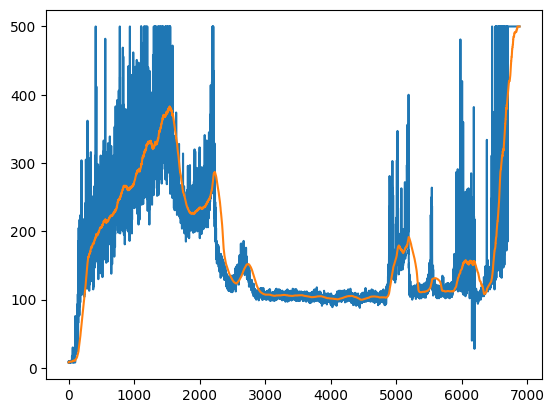

In [6]:
import matplotlib.pyplot as plt
# Generate recent 150 interval average
average_reward = []
for idx in range(len(reward_records)):
    avg_list = np.empty(shape=(1,), dtype=int)
    if idx < 150:
        avg_list = reward_records[:idx+1]
    else:
        avg_list = reward_records[idx-149:idx+1]
    average_reward.append(np.average(avg_list))
plt.plot(reward_records)
plt.plot(average_reward)